# Домашняя работа

Задания сгруппированы по темам.

## Тема 1. Комбинаторика

### Задача 1.8

> В конкурсе по 5 номинациям участвуют 10 кинофильмов. Сколько существует вариантов распределения призов, если по каждой номинации установлены: а) различные призы; б) одинаковые призы?

##### а)

In [2]:
import scipy.special as sc

print(10 ** 5)

100000


##### б)

In [3]:
round(sc.factorial(14) / (sc.factorial(5) * sc.factorial(14 - 5)))

2002

### Задача 1.9

> Сколько существует семизначных чисел, состоящих из цифр 4, 5 и 6, в которых цифра 4 повторяется 3 раза, а цифры 5 и 6 — по 2 раза?

In [4]:
round(sc.factorial(7) / (sc.factorial(3) * sc.factorial(2) * sc.factorial(2)))

210

### Задача 1.10

> Буквы Т, Е, И, Я, Р, О написаны на отдельных карточках. Ребенок берет карточки в случайном порядке и прикладывает одну к другой: а) 3 карточки; б) все 6 карточек. Какова вероятность того, что получится слово: а) «ТОР»; б) «ТЕОРИЯ»?

##### а)

In [5]:
1 / sc.perm(6, 3)

np.float64(0.008333333333333333)

##### б)

In [6]:
1 / sc.perm(6, 6)

np.float64(0.001388888888888889)

### Задача 1.11

> Используя условие примера 1.10, найти вероятность того, что получится слово «АНАНАС», если на отдельных карточках написаны три буквы А, две буквы Н и одна буква С.

In [7]:
n = sc.factorial(6) / (sc.factorial(3) * sc.factorial(2))
1 / n

np.float64(0.016666666666666666)

### Задача 1.16

> За круглым столом рассаживаются 5 мужчин и 5 женщин. Найти вероятность того, что: а) никакие два лица одного пола не сядут рядом; б) супруги сядут рядом, если эти мужчины и женщины образуют 5 супружеских пар.

##### а)

In [8]:
2 * sc.factorial(5) ** 2 / sc.factorial(10)

np.float64(0.007936507936507936)

##### б)

In [9]:
sc.factorial(5) * 2 ** 5 / sc.factorial(10)

np.float64(0.0010582010582010583)

### Задача 1.17

> В купейный вагон (9 купе по 4 места) семи пассажирам продано 7 билетов. Найти вероятности того, что пассажиры попали: а) в два купе; б) в семь купе; в) в три купе.

##### а)

In [10]:
n = sc.comb(36, 7)
m = sc.comb(9, 2) * sc.comb(8, 7)
m / n

np.float64(3.450060376056581e-05)

##### б)

In [11]:
n = sc.comb(36, 7)
m = sc.comb(9, 7) * 4 ** 7
m / n

np.float64(0.07065723650163878)

##### в)

In [12]:
n = sc.comb(36, 7)
m = sc.comb(9, 3) * (6 * sc.comb(4, 4) * sc.comb(4, 2) * sc.comb(4, 1) + 3 * sc.comb(4, 3) * sc.comb(4, 3) * sc.comb(4, 1) + 3 * sc.comb(4, 3) * sc.comb(4, 2) * sc.comb(4, 2))
m / n

np.float64(0.007728135242366742)

## Тема 2. Классическая вероятность

### Задача 1.38

> Пятитомное собрание сочинений расположено на полке в случайном порядке. Какова вероятность того, что книги стоят слева направо в порядке нумерации томов (от 1 до 5)?

In [13]:
round(1 / sc.factorial(5), 4)

np.float64(0.0083)

### Задача 1.43

> Наудачу взятый телефонный номер состоит из 5 цифр. Какова вероятность того, что в нем все цифры: а) различные; б) одинаковые; в) нечетные? Известно, что номер телефона не начинается с цифры ноль.

##### а)

In [14]:
round((9 * sc.perm(9, 4) / (9 * 10 ** 4)), 4)

np.float64(0.3024)

##### б)

In [15]:
round((sc.comb(9, 1) / (9 * 10 ** 4)), 4)

np.float64(0.0001)

##### в)

In [16]:
round((5 ** 5 / (9 * 10 ** 4)), 4)

0.0347

### Задача 1.48

> В старинной игре в кости необходимо было для выигрыша получить при бросании трех игральных костей сумму очков, превосходящую 10. Найти вероятности: а) выпадения 11 очков; б) выигрыша.

In [17]:
import itertools

arr = list(itertools.product(range(1, 7), repeat=3))
n = len(arr)

# а)
sum_11 = [x for x in arr if sum(x) == 11]
round(len(sum_11) / n, 4)

# б)
win = [x for x in arr if sum(x) > 10]
round(len(win) / n, 4)

0.5

## Тема 1_доп. Моделирование геометрической вероятности


> Смоделируйте вычисление геометрической вероятности (на примере из лекции про метание дротиков в игровой круг, площадь которого в два раза меньше площади стены). Показать теоретический расчет и графическую иллюстрацию для рассматриваемого примера.

In [18]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Polygon
import numpy as np

In [19]:
def points(n):
    a = 12
    fig, ax = plt.subplots(figsize=(5, 5))

    triangle = Polygon([[0, 0], [a, 0], [a / 2, a]])
    ax.add_patch(Rectangle((0, 0), a, a, facecolor='g'))
    ax.add_patch(triangle)
    x = np.random.uniform(0, a, n)
    y = np.random.uniform(0, a, n)
    ax.scatter(x, y, marker='.', c='black')

    inside = []
    for point_x, point_y in zip(x, y):
        if point_y <= 2 * point_x and point_y <= -2 * point_x + 2 * a:
            inside.append([point_x, point_y])

    probability = len(inside) / n
    plt.show()
    print(f'В треугольник из {n} точек попало {len(inside)}. Доля попавших = {probability}')

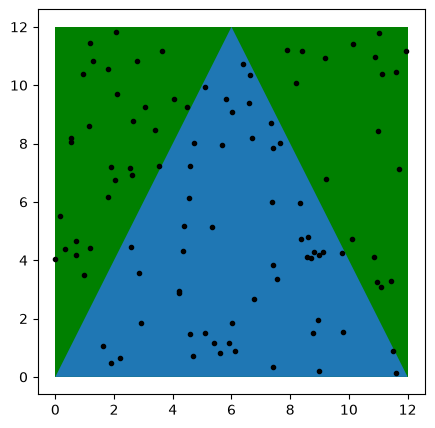

В треугольник из 100 точек попало 53. Доля попавших = 0.53


In [20]:
points(100)